Step1.Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.rcParams["figure.figsize"]=(10,5)

Step2.Load DataSet

In [3]:
df=pd.read_csv(
    "Housing_Prices_Dataset.csv"
)

print("Shape:")

print(df.shape)

df.head()

Shape:
(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Step3. Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


Step4. Column Name

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

Step5.Missing Values

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Step6. Duplicate Records

In [7]:
duplicates=df.duplicated().sum()

print(
    "Duplicates Records",
    duplicates
    )

Duplicates Records 0


Step7.Summary Statistics

In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Step8. Price Distribution

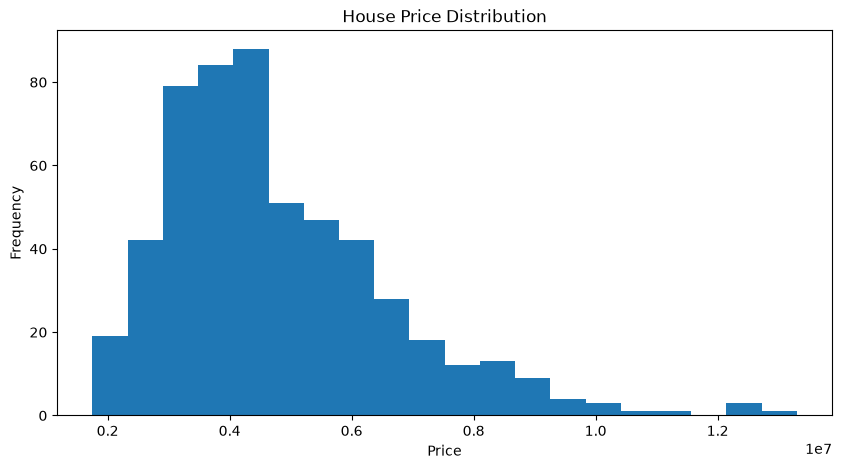

In [9]:
plt.hist(
    df["price"],
    bins=20
)

plt.title("House Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

Step9. Price Boxplot

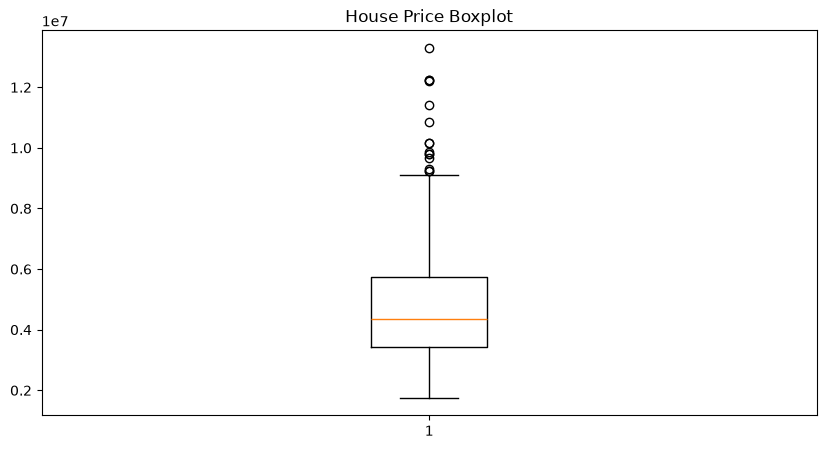

In [10]:
plt.boxplot(
    df["price"]
)

plt.title("House Price Boxplot")

plt.show()

Step10. Numerical Features Histogram

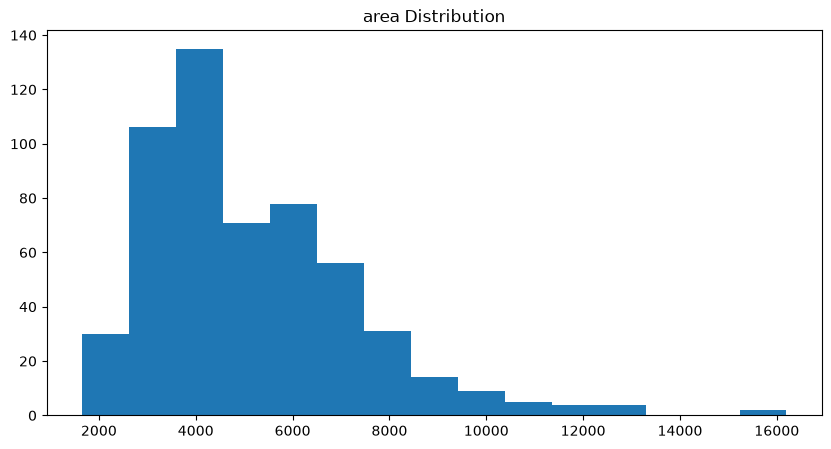

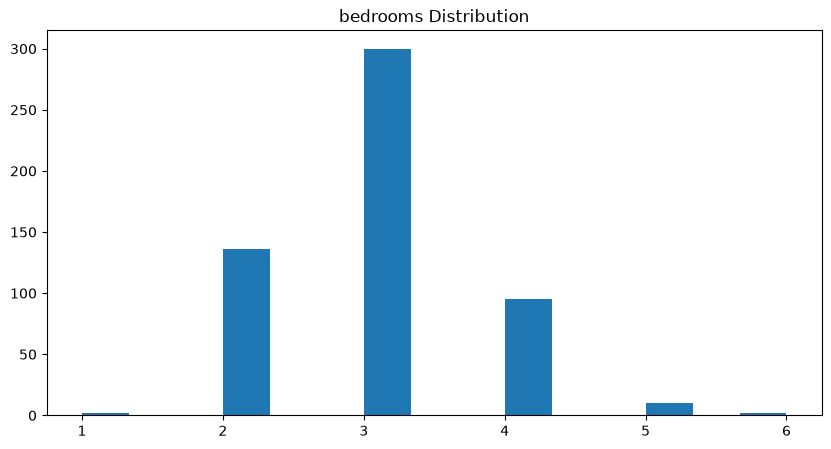

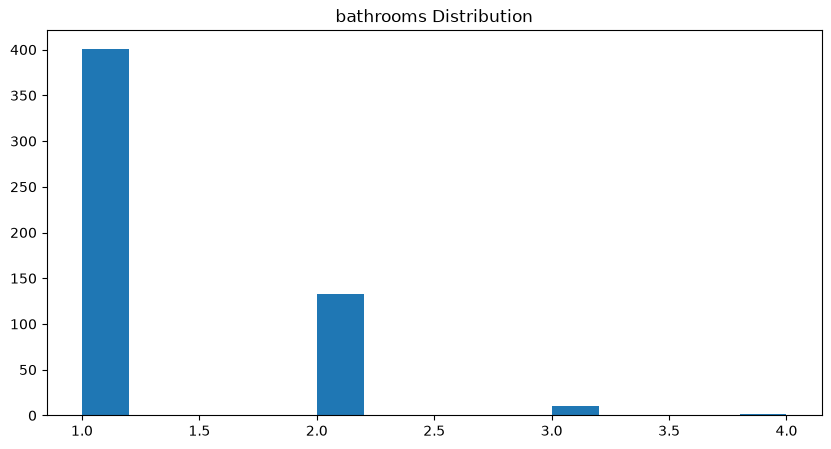

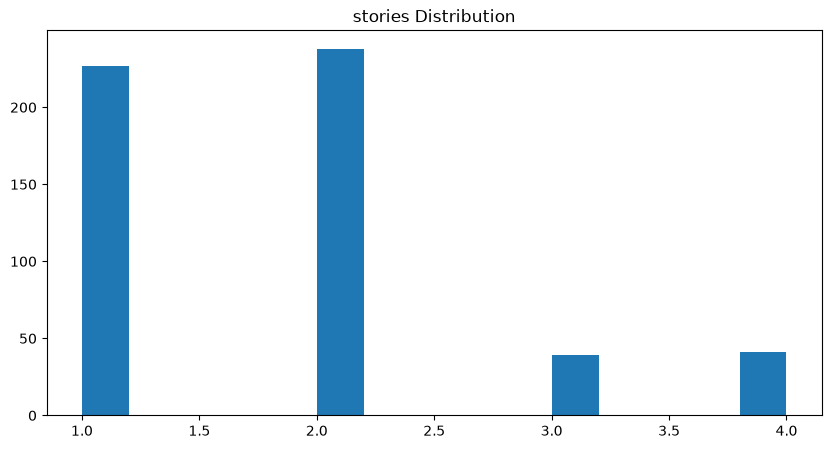

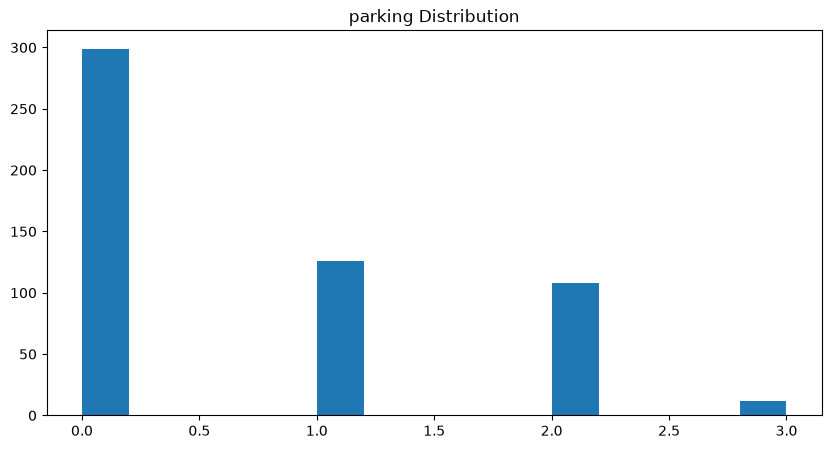

In [11]:
numerical_cols=[
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

for col in numerical_cols:
    plt.Figure()

    plt.hist(
        df[col],
        bins=15
    )

    plt.title(f"{col} Distribution")

    plt.show()

Step11.Correlation Matrix

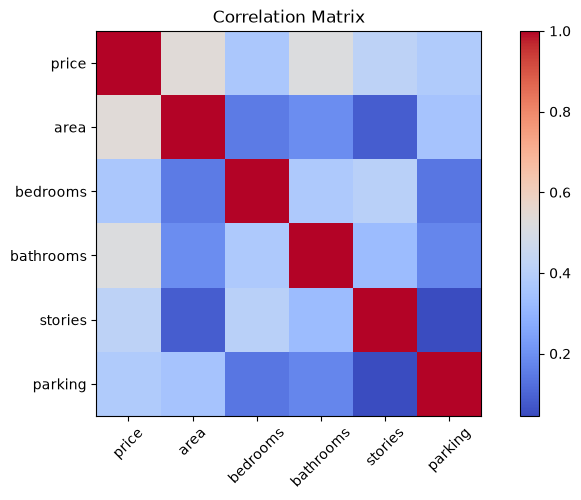

In [12]:
corr=df[
    [
        "price",
        "area",
        "bedrooms",
        "bathrooms",
        "stories",
        "parking"
    ]
].corr()

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

Step12.Area vs Price

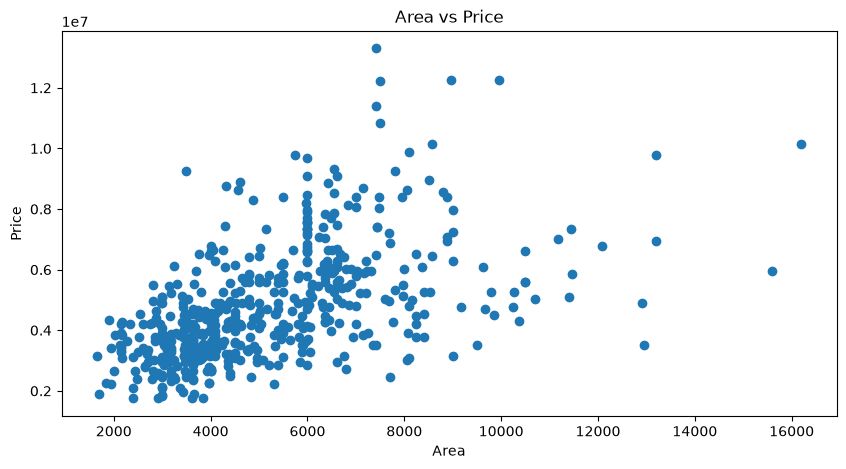

In [13]:
plt.scatter(
    df["area"],
    df["price"]
)

plt.xlabel("Area")

plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

Step13. Bedrooms vs Price

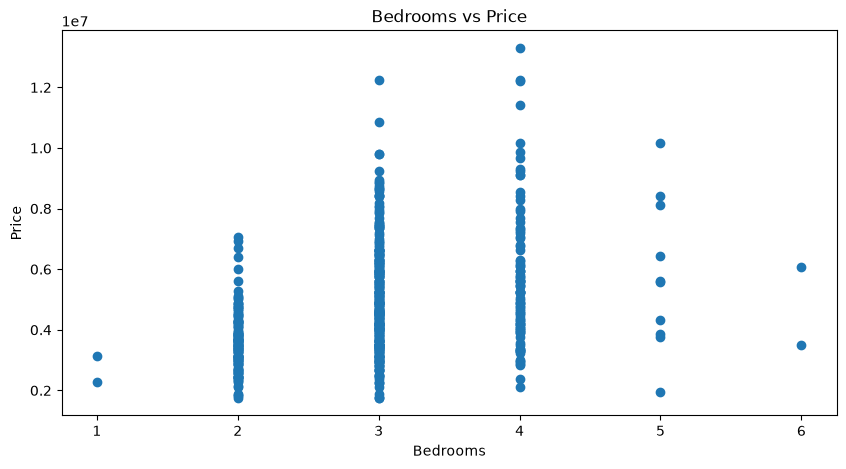

In [14]:
plt.scatter(
    df["bedrooms"],
    df["price"]
)

plt.xlabel("Bedrooms")

plt.ylabel("Price")

plt.title("Bedrooms vs Price")

plt.show()

Step14. Bathrooms vs Price

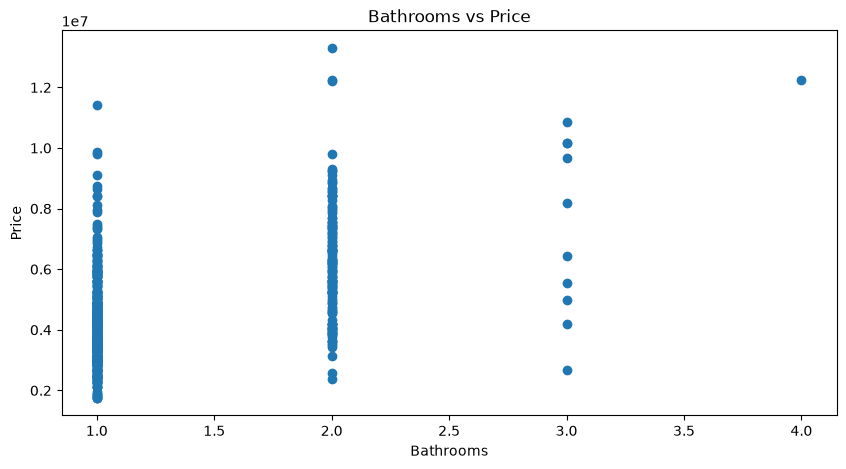

In [15]:
plt.scatter(
    df["bathrooms"],
    df["price"]
)

plt.xlabel("Bathrooms")

plt.ylabel("Price")

plt.title("Bathrooms vs Price")

plt.show()

Step15. Parking vs Price

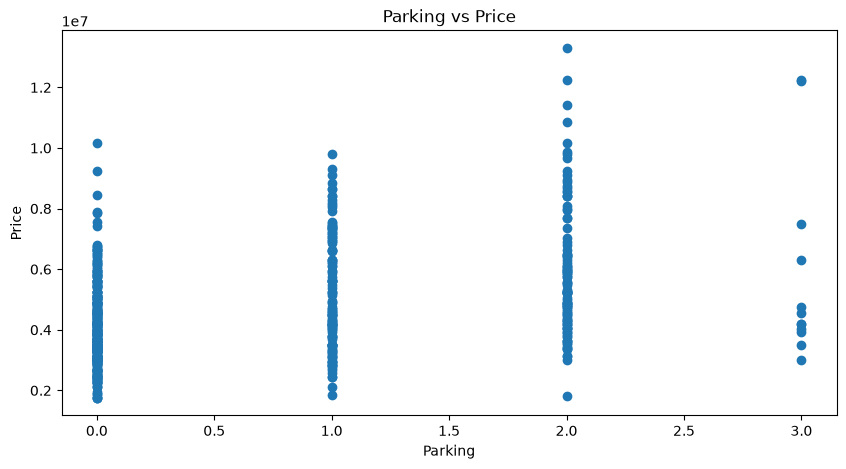

In [16]:
plt.scatter(
    df["parking"],
    df["price"]
)

plt.xlabel("Parking")

plt.ylabel("Price")

plt.title("Parking vs Price")

plt.show()

Step16.Analysis Categorial Feature

In [17]:
categorial_cols=[
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]

Step17. Counts Plot

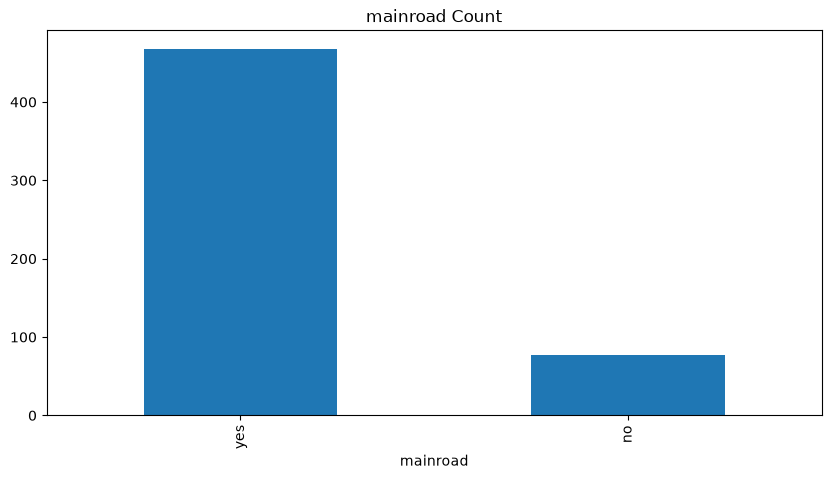

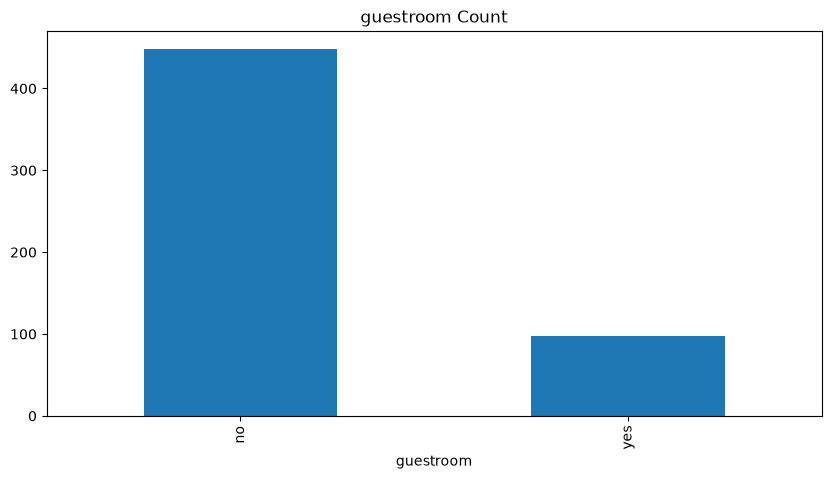

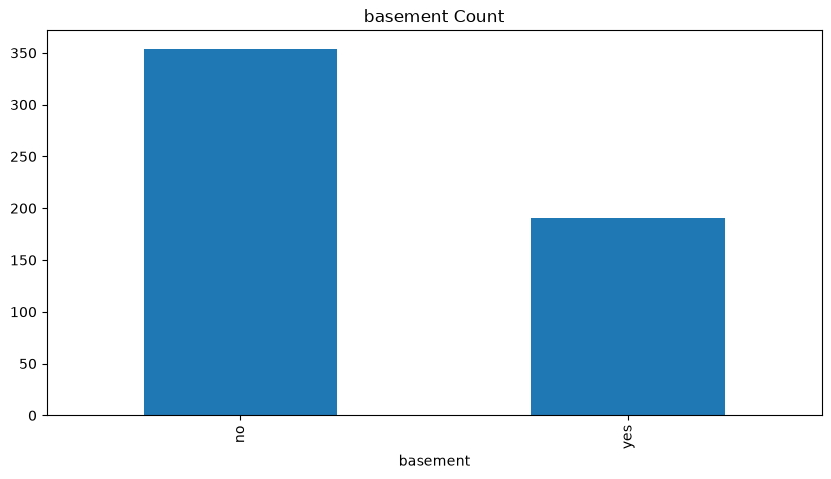

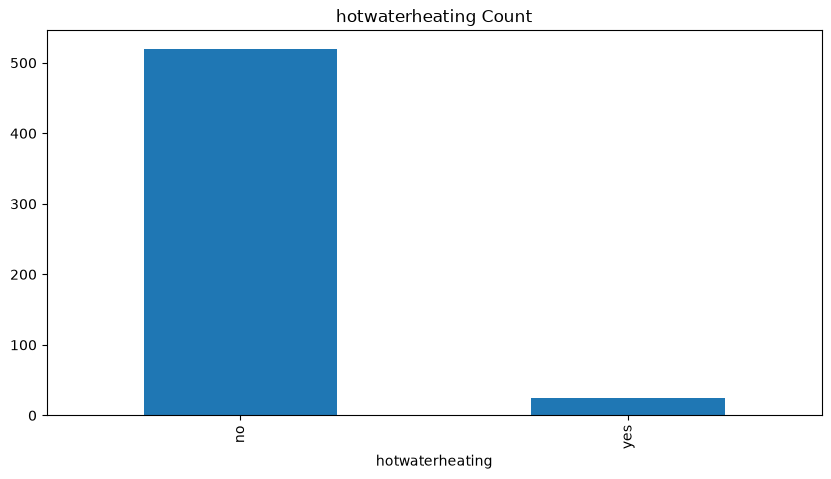

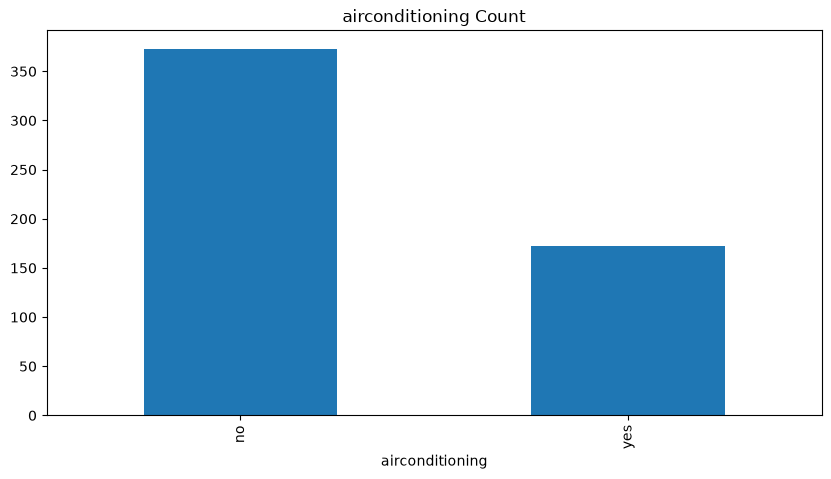

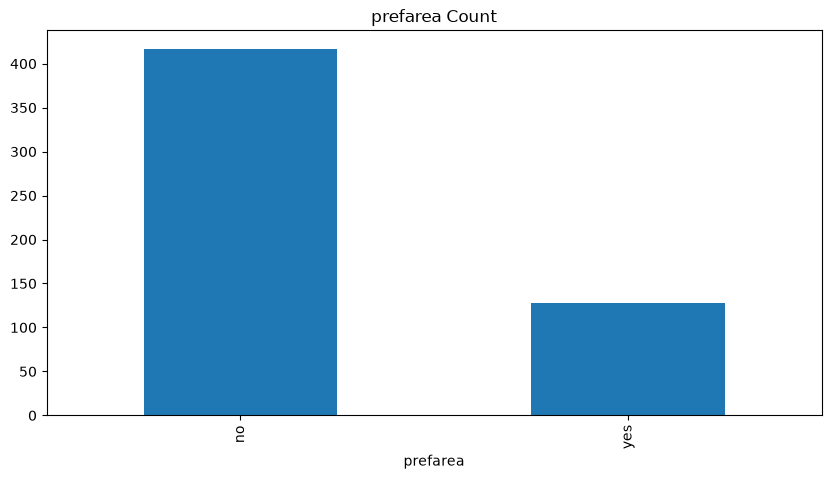

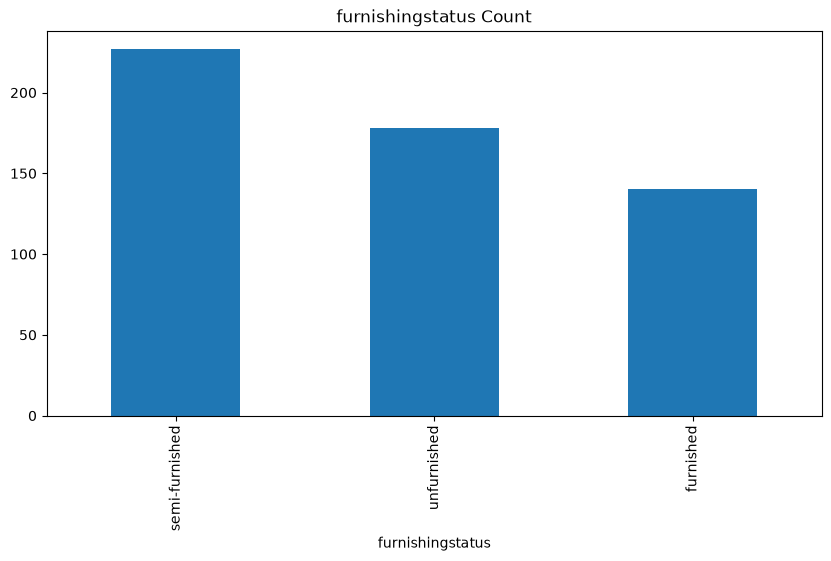

In [20]:
for col in categorial_cols:
    df[col].value_counts().plot(
        kind="bar"
    )

    plt.title(f"{col} Count")

    plt.show()

Step18. Average Price By Category

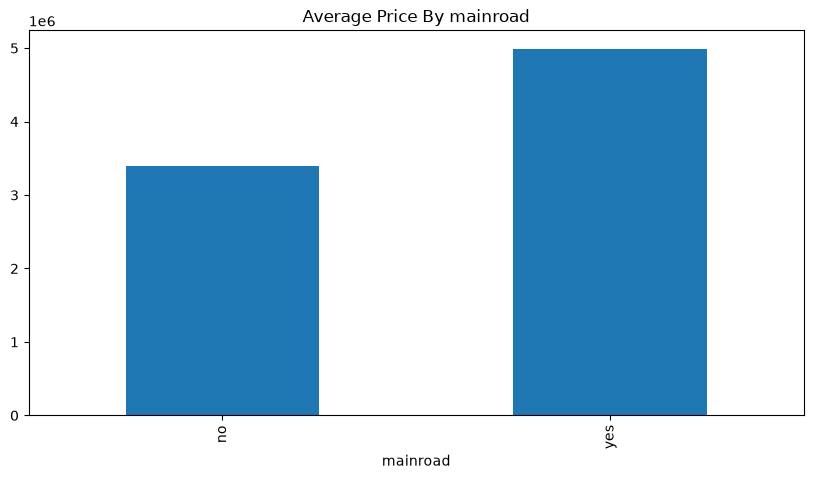

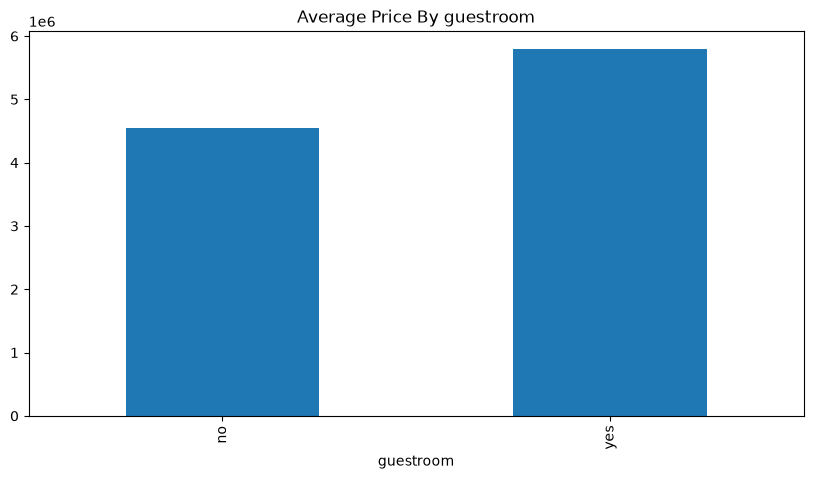

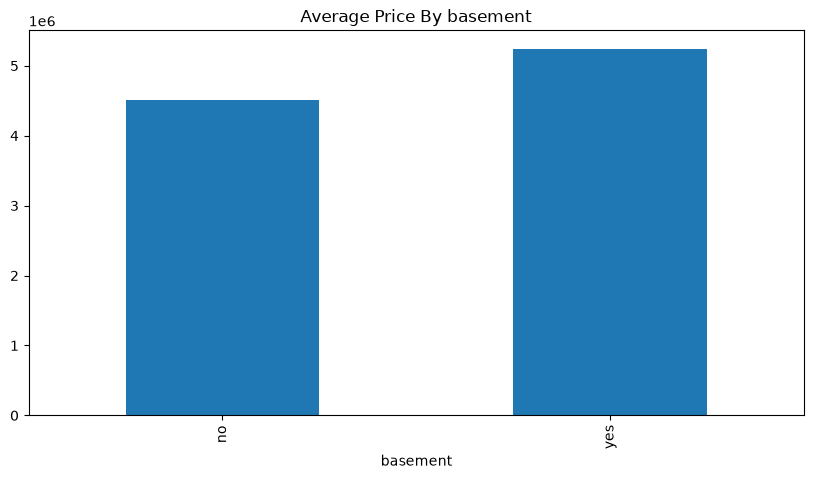

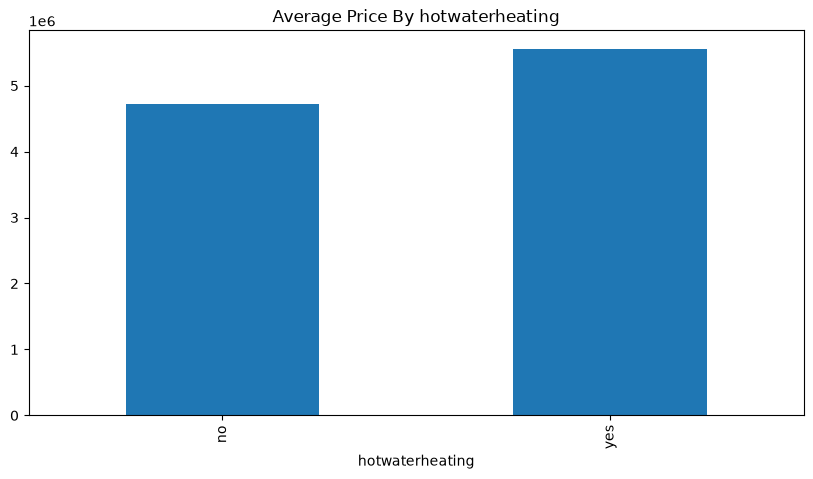

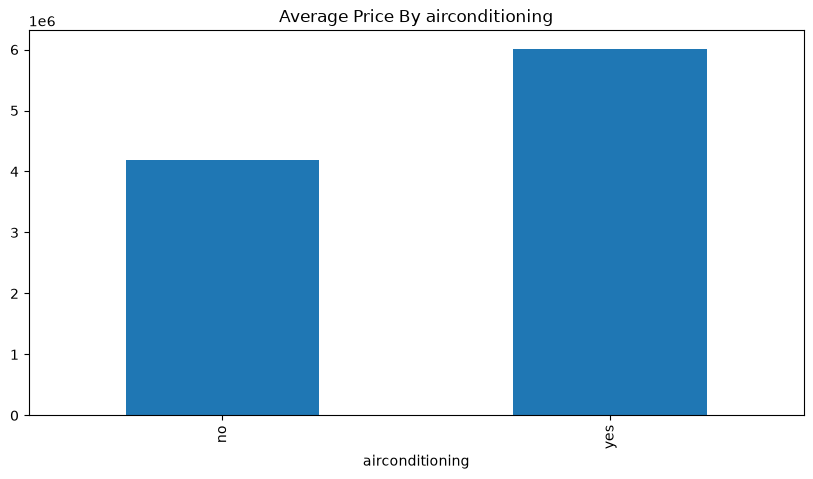

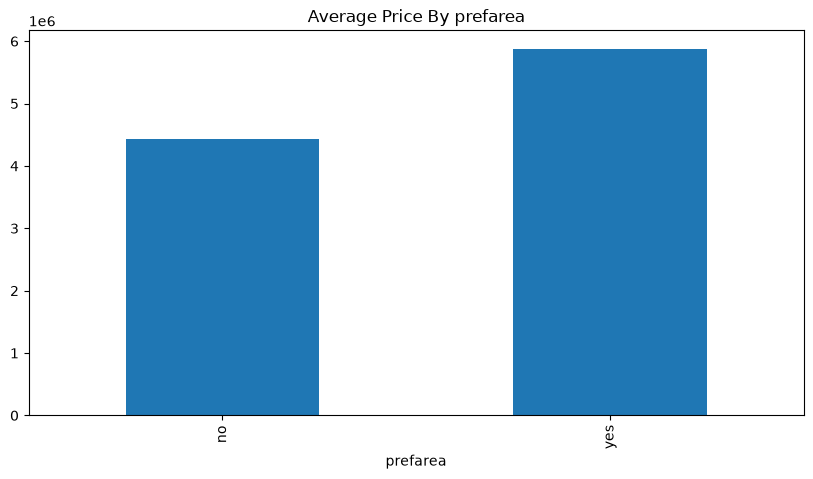

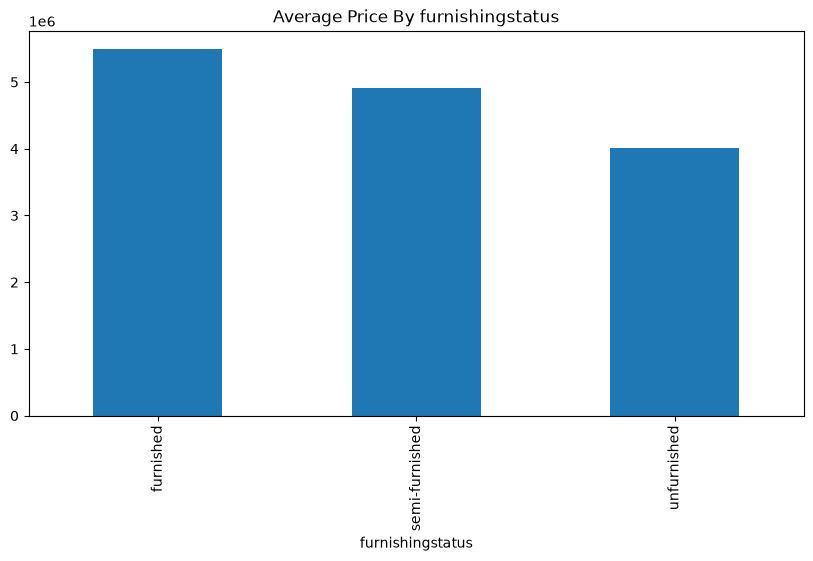

In [19]:
for col in categorial_cols:

    avg_price=(
            df.groupby(col)["price"]
            .mean()
    )

    avg_price.plot(
        kind="bar"
    )

    plt.title(f"Average Price By {col}")

    plt.show()

Step19. Encode Categorial Variables

In [21]:
encoder=LabelEncoder()

for col in categorial_cols:
    df[col]=encoder.fit_transform(
        df[col]
    )

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


Step20.Feature Matrix and Target

In [22]:
x=df.drop(
    "price",
    axis=1
)

y=df["price"]

Step21. Train Test Split

In [24]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)


Step22.Feature Scaling

In [ ]:
scaler=StandardScaler()

x_train=scaler.fit_transform(
    x_train
)

x_test=scaler.fit_transform(
    x_test
)

Step23. Linear Regression

In [25]:
lr=LinearRegression()

lr.fit(
    x_train,
    y_train
)

lr_pred=lr.predict(
    x_test
)

lr_mae=mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse=np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2=r2_score(
    y_test,
    lr_pred
)

print(lr_mae,lr_rmse,lr_r2)



979679.6912959905 1331071.4167895105 0.6494754192267804


Step24. Decision Tree

In [26]:
dt=DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    x_train,
    y_train
)

dt_pred=dt.predict(
    x_test
)

dt_mae=mean_absolute_error(
    y_test,
    dt_pred
)

dt_rmse=np.sqrt(
    mean_squared_error(
        y_test,
        dt_pred
    )
)

dt_r2=r2_score(
    y_test,
    dt_pred
)

print(
    dt_mae,
    dt_rmse,
    dt_r2
)

1222399.0825688073 1639566.2990811225 0.4681689010023007


Step25. Random Forest

In [27]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    x_train,
    y_train
)

rf_pred=rf.predict(
    x_test
)

rf_mae=mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse=np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2=r2_score(
    y_test,
    rf_pred
)

print(
    rf_mae,
    rf_rmse,
    rf_r2
)

1025289.6821100918 1401263.0789821919 0.6115321143409216


Step26. Model Comparison

In [28]:
results=pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2":[
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,9.796797e+05,1.331071e+06,0.649475
1,Decision Tree,1.222399e+06,1.639566e+06,0.468169
2,Random Forest,1.025290e+06,1.401263e+06,0.611532


Step27. Best Model

In [29]:
best_model=results.loc[
    results["R2"].idxmax()
]

best_model

Model    Linear Regression
MAE          979679.691296
RMSE         1331071.41679
R2                0.649475
Name: 0, dtype: object

Step28. Actual vs Predicted

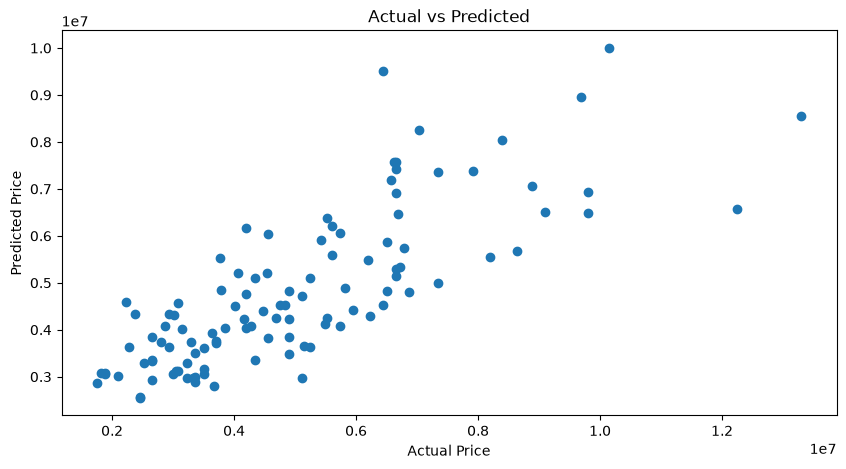

In [30]:
plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

Step29. Feature Importance

In [31]:
feature_importance=pd.DataFrame({
    "Feature":x.columns,
    "Importance":rf.feature_importances_
})

feature_importance=(
    feature_importance.sort_values(by="Importance",ascending=False)
)

feature_importance

,Feature,Importance
0,area,0.470417
2,bathrooms,0.152678
8,airconditioning,0.062343
9,parking,0.056608
3,stories,0.054772
11,furnishingstatus,0.050352
1,bedrooms,0.047950
6,basement,0.031695
10,prefarea,0.029982
7,hotwaterheating,0.017148
